In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# **PROJECT**
# **Comment Category Prediction Challenge :**

# Imports Libraries

In [ ]:
# Imports

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import gc
import psutil

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Data Loading

In [ ]:
DATA_PATH = "/kaggle/input/comment-category-prediction-challenge/"

train  = pd.read_csv(train_path)
test   = pd.read_csv(test_path)
sample = pd.read_csv(sample_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample shape:", sample.shape)


Train shape: (198000, 15)
Test shape: (102000, 14)
Sample shape: (102000, 2)


# Data Cleaning

In [ ]:
# Data Cleaning

for df in [train, test]:
    df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce', utc=True)
    for col in ['race', 'religion', 'gender']:
        df[col] = df[col].fillna('unknown')
    df['comment']    = df['comment'].fillna('')
    df['disability'] = df['disability'].fillna(0).astype(int)
    for col in ['upvote', 'downvote', 'if_1', 'if_2',
                'emoticon_1', 'emoticon_2', 'emoticon_3']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print('Nulls remaining:', train.isnull().sum().sum())
print('All clean!' if train.isnull().sum().sum() == 0 else 'WARNING: nulls remain')

Nulls remaining: 0
All clean!


# Text Cleaning

In [ ]:
# Text Cleaning


def clean_comment(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' url ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z0-9\s!?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train['clean_comment'] = train['comment'].apply(clean_comment)
test['clean_comment']  = test['comment'].apply(clean_comment)

print('Text cleaning done.')
print('Sample:', train['clean_comment'].iloc[0][:100])

Text cleaning done.
Sample: she might be a bright spot for a party keou on oahu dominated by greedy criminals or ethically chall


# **EDA** :

# Dataset Overview

In [ ]:
print('DATASET OVERVIEW')

print(f'\nTrain shape : {train.shape}')
print(f'Test  shape : {test.shape}')

DATASET OVERVIEW

Train shape : (198000, 16)
Test  shape : (102000, 15)


In [ ]:
print('Column Info')
print(train.dtypes)

Column Info
created_date     datetime64[ns, UTC]
post_id                        int64
emoticon_1                     int64
emoticon_2                     int64
emoticon_3                     int64
upvote                         int64
downvote                       int64
if_1                           int64
if_2                           int64
race                          object
religion                      object
gender                        object
disability                     int64
comment                       object
label                          int64
clean_comment                 object
dtype: object


In [ ]:
print('Basic Statistics')
display(train.describe().round(2))

Basic Statistics


,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,label
count,198000.00,198000.00,198000.00,198000.00,198000.00,198000.00,198000.00,198000.00,198000.00,198000.00
mean,68.45,0.28,0.05,0.12,2.61,0.67,1.91,7.96,0.01,0.79
std,27.95,1.02,0.26,0.48,5.05,2.04,25.64,14.84,0.12,0.98
min,20.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,0.00,0.00
25%,39.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,0.00,0.00
50%,72.00,0.00,0.00,0.00,1.00,0.00,0.00,6.00,0.00,0.00
75%,72.00,0.00,0.00,0.00,3.00,1.00,4.00,10.00,0.00,2.00
max,129.00,47.00,11.00,17.00,201.00,107.00,1860.00,1833.00,1.00,3.00


# Missing Values Analysis

In [ ]:
if train.isnull().sum().sum() == 0:
    print("No missing values in dataset.")
else:
    print("Missing values found.")

No missing values in dataset.


# Target Label Distribution

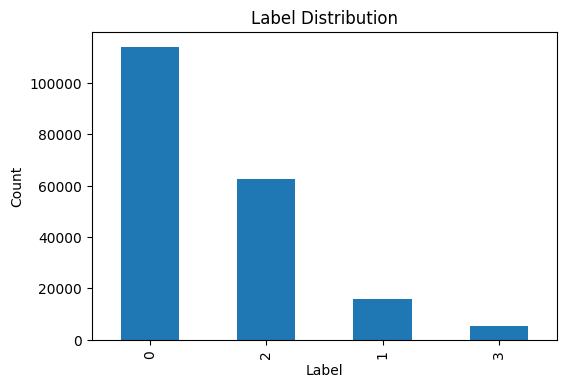

label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6,4))
train['label'].value_counts().plot(kind='bar')
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

print(train['label'].value_counts(normalize=True))


# Comment Text Analysis

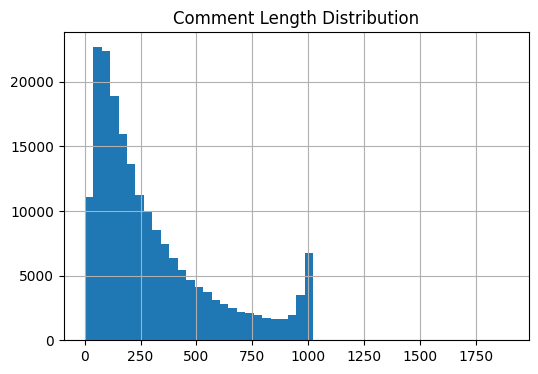

count    198000.000000
mean        302.909364
std         266.441749
min           0.000000
25%         102.000000
50%         211.000000
75%         419.000000
max        1892.000000
Name: comment_length, dtype: float64

In [ ]:
train['comment'] = train['comment'].astype(str)
train['comment_length'] = train['comment'].apply(len)

plt.figure(figsize=(6,4))
train['comment_length'].hist(bins=50)
plt.title("Comment Length Distribution")
plt.show()

train['comment_length'].describe()


# Correlation Heatmap

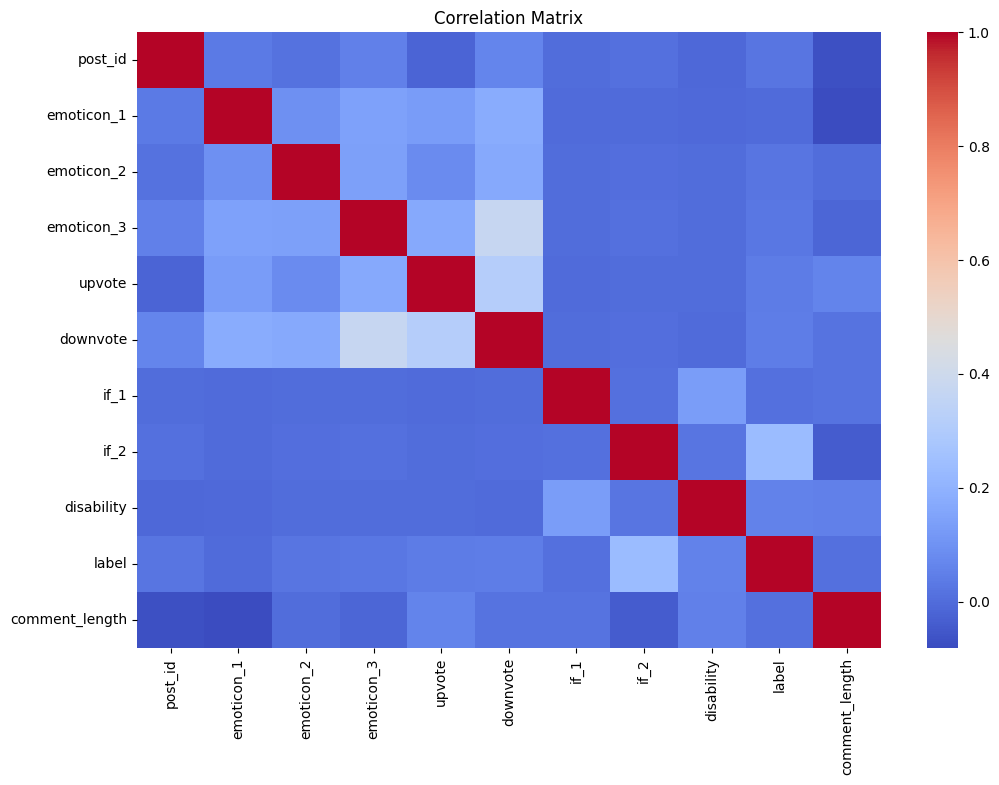

In [ ]:
numeric_data = train.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_data.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()
